✅ Dataset loaded: 30 prompts
✅ Schema validation passed


/var/folders/zh/yms1gjd96710vz87_cq258l40000gn/T/ipykernel_83891/2266295991.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tier_counts.index.map(tier_labels), y=tier_counts.values, palette="Blues_d")


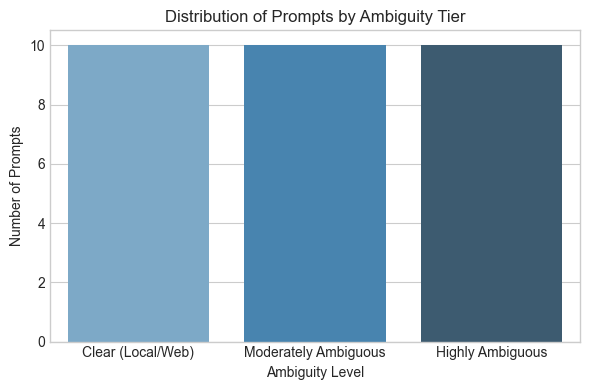

📊 Ground Truth × Ambiguity Tier:
                    Clear (Local/Web)  Moderately Ambiguous  Highly Ambiguous
ground_truth                                                                 
Local (Historical)                  5                     7                 5
Web (Real-time)                     5                     3                 5


/var/folders/zh/yms1gjd96710vz87_cq258l40000gn/T/ipykernel_83891/2266295991.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tags_df, x="tag", y="count", palette="Greens_d")


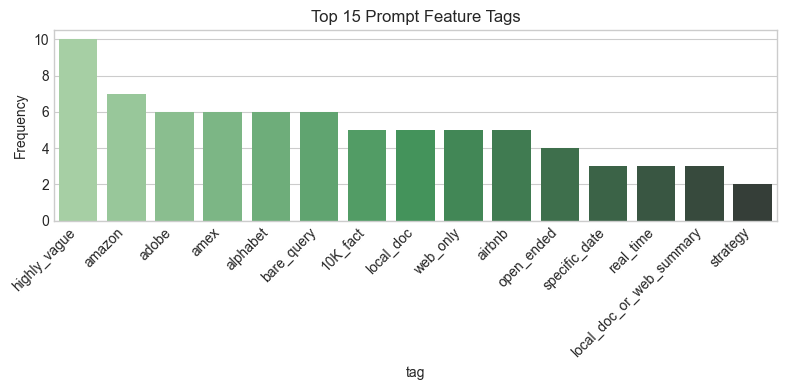


🔍 Tier 1 (Clear (Local/Web)):
  • ID: 9 | GT: web
    "What is Alphabet's current trailing P/E ratio?"
    Tags: ['alphabet', 'valuation_metric', 'real_time', 'financial_market', 'web_only']
------------------------------------------------------------
  • ID: 2 | GT: local
    "What are the two main customer group strategies Adobe focuses on in its FY2025 annual report?"
    Tags: ['adobe', 'strategy', '10K_fact', 'customer_segments', 'local_doc']
------------------------------------------------------------

🔍 Tier 2 (Moderately Ambiguous):
  • ID: 19 | GT: local
    "What makes American Express's business model different from Visa and Mastercard?"
    Tags: ['amex', 'differentiated_model', 'local_doc_or_web_analysis', 'competitive_positioning']
------------------------------------------------------------
  • ID: 12 | GT: local
    "What are the main risks Airbnb faces as a business?"
    Tags: ['airbnb', 'risk_factors', '10K_section_or_web_analysis', 'investment_research']
----------

In [3]:
# Cell 1 [Markdown]
# # 📊 Dataset Exploration & Ambiguity Validation
# This notebook validates the prompt dataset schema, explores ambiguity tier distribution, 
# analyzes prompt feature tags, and provides qualitative examples for each tier.
 
# Cell 2 [Code]
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast
 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("pastel")
 
# Paths
DATA_DIR = Path("../data/dataset")
PROMPT_PATH = DATA_DIR / "prompts_dataset.json"
 
# Load dataset
with open(PROMPT_PATH, "r") as f:
    raw_data = json.load(f)
 
df_prompts = pd.DataFrame(raw_data)
 
# Handle list column (prompt_tags)
if df_prompts["prompt_tags"].dtype == "object":
    df_prompts["prompt_tags"] = df_prompts["prompt_tags"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
 
print(f"✅ Dataset loaded: {len(df_prompts)} prompts")
df_prompts.head()
 
# Cell 3 [Code]
# Schema Validation
required_cols = {"query_id", "prompt", "ambiguity_tier", "ground_truth", "prompt_tags"}
missing = required_cols - set(df_prompts.columns)
assert len(missing) == 0, f"Missing columns: {missing}"
 
assert df_prompts["ambiguity_tier"].isin([1, 2, 3]).all(), "Invalid ambiguity_tier values"
assert df_prompts["ground_truth"].isin(["local", "web", "uncertain"]).all(), "Invalid ground_truth values"
print("✅ Schema validation passed")
 
# Cell 4 [Code]
# Distribution of Ambiguity Tiers
tier_counts = df_prompts["ambiguity_tier"].value_counts().sort_index()
tier_labels = {1: "Clear (Local/Web)", 2: "Moderately Ambiguous", 3: "Highly Ambiguous"}
 
plt.figure(figsize=(6, 4))
sns.barplot(x=tier_counts.index.map(tier_labels), y=tier_counts.values, palette="Blues_d")
plt.title("Distribution of Prompts by Ambiguity Tier")
plt.ylabel("Number of Prompts")
plt.xlabel("Ambiguity Level")
plt.tight_layout()
plt.show()
 
# Cell 5 [Code]
# Ground Truth vs Ambiguity Tier Cross-Tab
ct = pd.crosstab(df_prompts["ground_truth"], df_prompts["ambiguity_tier"])
ct.index = ct.index.map({"local": "Local (Historical)", "web": "Web (Real-time)", "uncertain": "Ambiguous"})
ct.columns = [tier_labels[i] for i in ct.columns]
print("📊 Ground Truth × Ambiguity Tier:")
print(ct)
 
# Cell 6 [Code]
# Prompt Tag Frequency Analysis
from collections import Counter
all_tags = [tag for sublist in df_prompts["prompt_tags"] for tag in sublist]
tag_counts = Counter(all_tags).most_common(15)
 
tags_df = pd.DataFrame(tag_counts, columns=["tag", "count"])
plt.figure(figsize=(8, 4))
sns.barplot(data=tags_df, x="tag", y="count", palette="Greens_d")
plt.xticks(rotation=45, ha="right")
plt.title("Top 15 Prompt Feature Tags")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
 
# Cell 7 [Code]
# Sample Prompts per Tier
for tier in [1, 2, 3]:
    sample = df_prompts[df_prompts["ambiguity_tier"] == tier].sample(2, random_state=42)
    print(f"\n🔍 Tier {tier} ({tier_labels[tier]}):")
    for _, row in sample.iterrows():
        print(f"  • ID: {row['query_id']} | GT: {row['ground_truth']}")
        print(f"    \"{row['prompt']}\"")
        print(f"    Tags: {row['prompt_tags']}")
        print("-" * 60)